# Food category EDA

Explores IFCT-derived food risk rows, packaging-group mapping, requirement bands, and whether those bands share units with the materials table.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12

import sys

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


def unique_report(df, max_levels=40):
    rows = []
    for col in df.columns:
        s = df[col]
        n_unique = s.nunique(dropna=False)
        n_missing = int(s.isna().sum())
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "n_unique": n_unique,
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / len(df), 2),
        })
        print(f"\n=== {col}  ({s.dtype})  unique={n_unique}  missing={n_missing} ===")
        vc = s.value_counts(dropna=False)
        if n_unique <= max_levels:
            display(vc.to_frame("count"))
        else:
            print(f"High cardinality — top {max_levels}:")
            display(vc.head(max_levels).to_frame("count"))
    return pd.DataFrame(rows)


def iqr_outliers(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return s, np.nan, np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < lo) | (s > hi)], lo, hi


def wvtr_to_g_m2_day(value, unit):
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    u = str(unit).strip().lower().replace(" ", "")
    if u in {"g/m2day", "g/m2/day", "gm/m2day"}:
        return float(value)
    if u in {"g/m2s", "g/m2/s", "gm/m2s"}:
        return float(value) * 86400.0
    return np.nan


def otr_to_cm3_m2_day(value, unit):
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    u = str(unit).strip().lower().replace(" ", "")
    if u in {"cm3/m2day", "cm3/m2/day"}:
        return float(value)
    if u in {"cm3/m2s", "cm3/m2/s"}:
        return float(value) * 86400.0
    return np.nan


In [2]:
foods = pd.read_csv(ROOT / "data/processed/food_risk_profile.csv")
joined = pd.read_csv(ROOT / "data/processed/food_packaging_requirements.csv")
reqs = pd.read_csv(ROOT / "data/raw/packaging_materials/food_requirements.csv")
mat = pd.read_csv(ROOT / "data/processed/materials_permeability_enriched.csv")
index = pd.read_csv(ROOT / "data/raw/food_ctegory/index.csv", nrows=5)

from src.preprocessing.food_category.food_category_map import FOOD_CATEGORY_MAP

print("foods", foods.shape, "joined", joined.shape, "reqs", reqs.shape)
display(foods.head(3))
display(foods.dtypes.to_frame("dtype"))
print("index.csv sample columns (first 12):", list(index.columns[:12]))
print("fams in food_risk_profile.csv?", "fams" in foods.columns)
print("fams is used in oxidation_risk_index but dropped from the saved food table.")


foods (542, 24) joined (540, 30) reqs (9, 6)


,code,name,scie,lang,grup,regn,tags,water,fatce,protcnt,choavldf,fibtg,orgac,vitc,polyph,cartoid,fasat,fauns,fapu,starch,moisture_class,oxidation_risk_index,moisture_barrier_requirement,food_risk_profile
0,A001,"Amaranth seed, black",Amaranthus cruentus,A. Moricha guti; H. Ramdana; Kan. Danthu beeja...,Cereals and Millets,1,vegetarian eggetarian fishetarian veg,9.89,5.74,14.59,59.98,7.02,0.35757,0.0,0.01250,0.000121,1.280,3.312,2.279,55.83,low,3.943374,high_for_moisture_gain,high_for_moisture_gain__medium_oxidation
1,A002,"Amaranth seed, pale brown",Amaranthus cruentus,A. Moricha guti; G. Rajagaro; H. Ramdana; Kan....,Cereals and Millets,6,vegetarian eggetarian fishetarian veg,9.20,5.56,13.27,61.46,7.47,0.34132,0.0,0.01175,0.000060,1.140,3.309,2.266,59.33,low,3.899382,high_for_moisture_gain,high_for_moisture_gain__medium_oxidation
2,A003,Bajra,Pennisetum typhoideum,"A., Kash. Baajra; B. Bajra; E. Pearl millet; G...",Cereals and Millets,6,vegetarian eggetarian fishetarian veg,8.97,5.43,10.96,61.78,11.49,0.05608,0.0,0.06771,0.000293,0.875,3.031,1.984,55.21,low,3.592820,high_for_moisture_gain,high_for_moisture_gain__medium_oxidation


,dtype
code,object
name,object
scie,object
lang,object
grup,object
regn,int64
tags,object
water,float64
fatce,float64
protcnt,float64


index.csv sample columns (first 12): ['code', 'name', 'scie', 'lang', 'grup', 'regn', 'tags', 'enerc', 'enerc_e', 'water', 'water_e', 'ash']
fams in food_risk_profile.csv? False
fams is used in oxidation_risk_index but dropped from the saved food table.


## Unique values and counts

In [3]:
food_col_summary = unique_report(foods, max_levels=25)
display(food_col_summary)



=== code  (object)  unique=542  missing=0 ===
High cardinality — top 25:


,count
code,
A001,1
A002,1
A003,1
A004,1
A005,1
A006,1
A007,1
A008,1
A009,1



=== name  (object)  unique=540  missing=0 ===
High cardinality — top 25:


,count
name,
Cat fish,2
Crab,2
Bajra,1
Barley,1
Jowar,1
"Maize, dry",1
"Maize, tender, local",1
"Maize, tender, sweet",1
Quinoa,1



=== scie  (object)  unique=277  missing=117 ===
High cardinality — top 25:


...


=== moisture_barrier_requirement  (object)  unique=3  missing=0 ===


,count
moisture_barrier_requirement,
high,323
medium,113
high_for_moisture_gain,106



=== food_risk_profile  (object)  unique=5  missing=0 ===


,count
food_risk_profile,
high__medium_oxidation,323
medium__medium_oxidation,111
high_for_moisture_gain__medium_oxidation,67
high_for_moisture_gain__high_oxidation,39
medium__high_oxidation,2


,column,dtype,n_unique,n_missing,pct_missing
0,code,object,542,0,0.00
1,name,object,540,0,0.00
2,scie,object,277,117,21.59
3,lang,object,400,112,20.66
4,grup,object,20,0,0.00
5,regn,int64,7,0,0.00
6,tags,object,4,0,0.00
7,water,float64,474,0,0.00
8,fatce,float64,302,0,0.00
9,protcnt,float64,438,0,0.00


## Category, moisture, and risk-profile mix

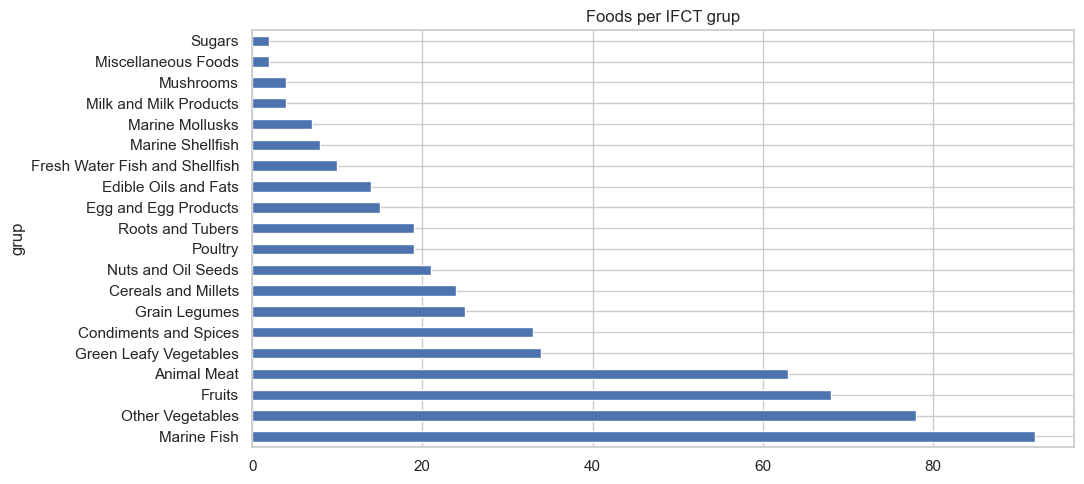

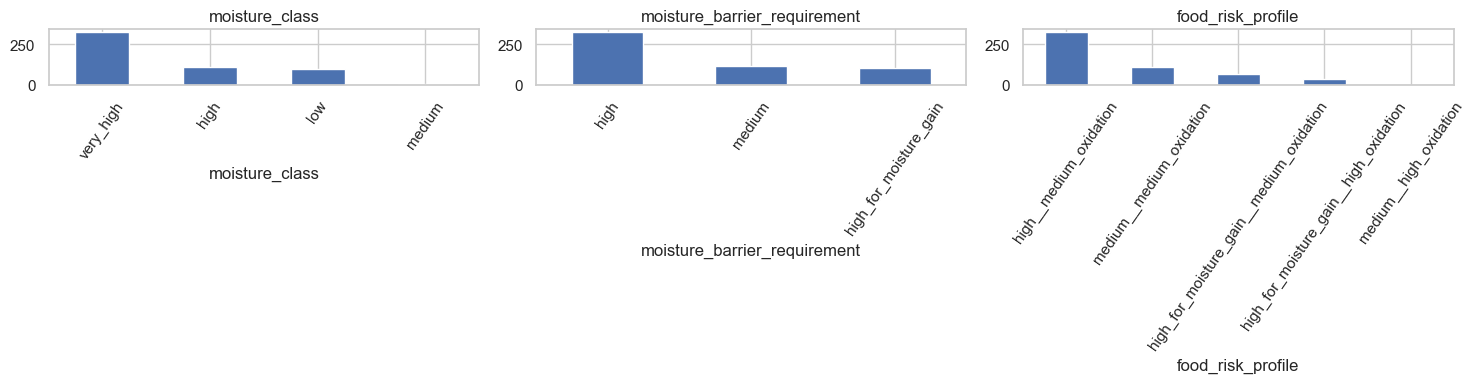

moisture_class,high,low,medium,very_high
grup,,,,
Animal Meat,32,0,0,31
Cereals and Millets,2,22,0,0
Condiments and Spices,4,13,2,14
Edible Oils and Fats,0,14,0,0
Egg and Egg Products,11,0,0,4
Fresh Water Fish and Shellfish,1,0,0,9
Fruits,9,4,3,52
Grain Legumes,0,25,0,0
Green Leafy Vegetables,2,0,0,32


food_risk_profile,high__medium_oxidation,high_for_moisture_gain__high_oxidation,high_for_moisture_gain__medium_oxidation,medium__high_oxidation,medium__medium_oxidation
moisture_class,,,,,
high,0,0,0,2,110
low,0,37,62,0,0
medium,0,2,5,0,1
very_high,323,0,0,0,0


,count
tags,
vegetarian eggetarian fishetarian veg,328
fishetarian nonveg,117
nonveg,82
eggetarian fishetarian nonveg,15


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
foods["grup"].value_counts().plot(kind="barh", ax=ax)
ax.set_title("Foods per IFCT grup")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
foods["moisture_class"].value_counts().plot(kind="bar", ax=axes[0], title="moisture_class")
foods["moisture_barrier_requirement"].value_counts().plot(kind="bar", ax=axes[1], title="moisture_barrier_requirement")
foods["food_risk_profile"].value_counts().plot(kind="bar", ax=axes[2], title="food_risk_profile")
for ax in axes:
    ax.tick_params(axis="x", rotation=55)
plt.tight_layout()
plt.show()

display(pd.crosstab(foods["grup"], foods["moisture_class"]))
display(pd.crosstab(foods["moisture_class"], foods["food_risk_profile"]))
display(foods["tags"].value_counts().to_frame("count"))


## Composition statistics and outliers
IFCT nutrient amounts are per 100 g food (typical IFCT convention). That is **not** the same physical quantity as material WVTR/OTR.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
regn,542.0,3.402214,2.143777,1.000,1.000000,1.000000,1.000000,3.000000,6.000000,6.000000,6.000000,10.000000
water,542.0,66.378210,29.567544,0.000,0.000000,5.244000,68.400000,77.240000,85.547500,92.969500,94.736200,95.770000
fatce,542.0,6.820830,17.605904,0.030,0.120000,0.160000,0.370000,1.065000,4.430000,39.484000,100.000000,100.010000
protcnt,542.0,10.685314,8.817749,0.000,0.000000,0.422000,1.490000,10.365000,19.687500,22.489000,24.198300,37.800000
choavldf,542.0,10.822177,19.050177,0.000,0.000000,0.000000,0.000000,2.695000,11.397500,64.050500,74.864900,84.870000
fibtg,542.0,3.881236,6.519471,0.000,0.000000,0.000000,0.000000,1.860000,4.425000,17.009000,32.335900,47.550000
orgac,542.0,0.221295,0.452683,0.000,0.000000,0.000000,0.000000,0.035655,0.235700,0.884244,2.282935,4.074200
vitc,542.0,0.012678,0.029675,0.000,0.000000,0.000000,0.000000,0.000000,0.011440,0.071822,0.130540,0.252000
polyph,542.0,0.062297,0.251277,0.000,0.000000,0.000000,0.000000,0.006910,0.038238,0.220750,0.903540,2.986000
cartoid,542.0,0.001323,0.005804,0.000,0.000000,0.000000,0.000000,0.000078,0.000364,0.005826,0.021693,0.101812


,column,n_outliers,fence_lo,fence_hi,out_min,out_max
13,starch,108,-2.940000,4.900000,4.990000,76.140000
1,water,107,42.678750,111.268750,0.000000,42.510000
9,cartoid,96,-0.000546,0.000910,0.000924,0.101812
2,fatce,75,-5.720000,10.520000,10.540000,100.010000
8,polyph,74,-0.057356,0.095594,0.096420,2.986000
10,fasat,71,-1.637319,2.981191,2.998000,90.860000
7,vitc,70,-0.017160,0.028600,0.029080,0.252000
12,fapu,70,-0.705500,1.550500,1.596000,76.780000
11,fauns,68,-2.204237,4.179742,4.339000,94.280000
4,choavldf,66,-17.096250,28.493750,29.460000,84.870000


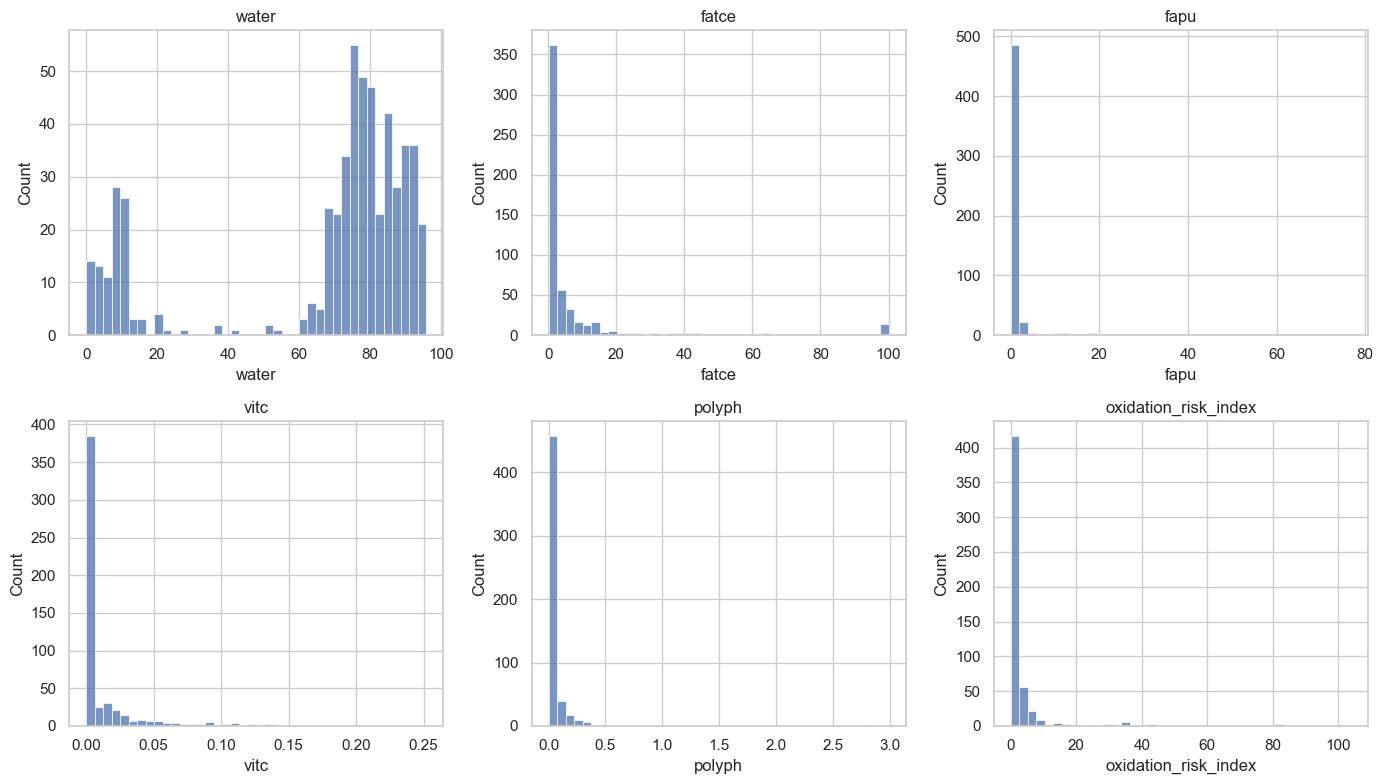

In [5]:
num_cols = [c for c in foods.columns if foods[c].dtype != "object"]
display(foods[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

outlier_rows = []
for col in num_cols:
    outs, lo, hi = iqr_outliers(foods[col])
    outlier_rows.append({
        "column": col, "n_outliers": len(outs),
        "fence_lo": lo, "fence_hi": hi,
        "out_min": outs.min() if len(outs) else np.nan,
        "out_max": outs.max() if len(outs) else np.nan,
    })
display(pd.DataFrame(outlier_rows).sort_values("n_outliers", ascending=False))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), ["water", "fatce", "fapu", "vitc", "polyph", "oxidation_risk_index"]):
    sns.histplot(foods[col].dropna(), bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## Moisture and oxidation bins vs cut definitions
- moisture_class: water ≤20 low, ≤50 medium, ≤75 high, else very_high
- oxidation bands on the index: ≤0 low, ≤10 medium, else high

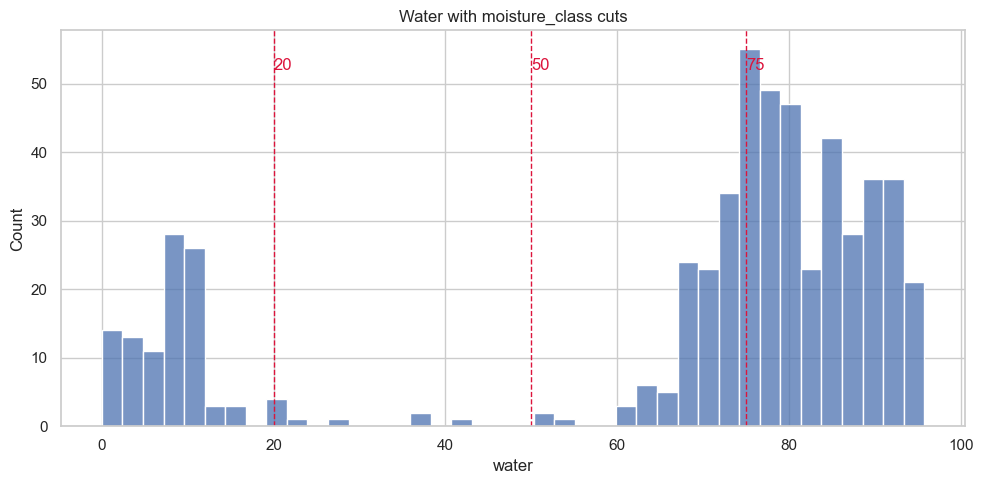

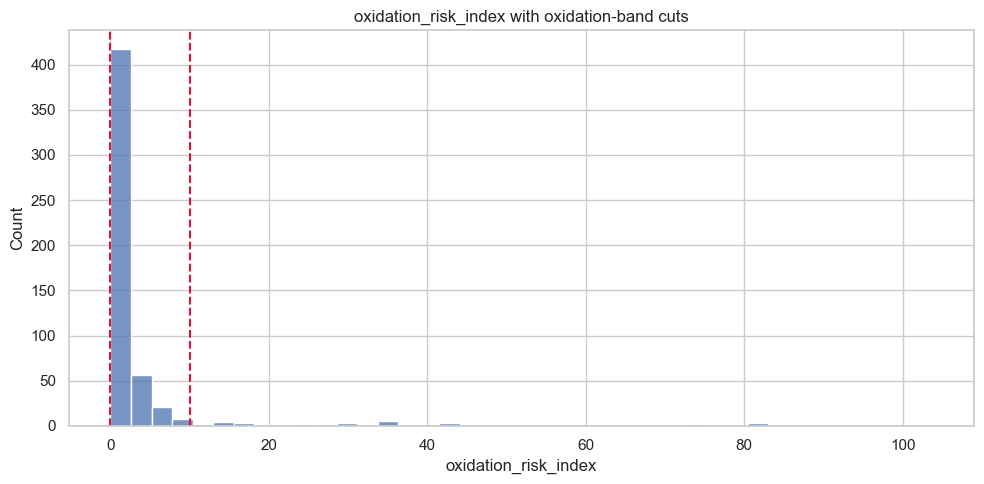

,count,mean,std,min,25%,50%,75%,max
moisture_class,,,,,,,,
high,112.0,70.066696,4.424963,51.42,68.3725,71.095,73.3475,74.88
low,99.0,7.547576,4.189219,0.00,4.6250,8.970,9.8800,19.69
medium,8.0,28.405000,8.979661,20.06,21.3325,24.250,36.5300,42.51
very_high,323.0,84.071424,6.024814,75.11,78.5950,84.020,89.4900,95.77


,count,mean,std,min,25%,50%,75%,max
food_risk_profile,,,,,,,,
high__medium_oxidation,323.0,0.653559,0.815370,0.012000,0.196918,0.362438,0.746000,6.795998
high_for_moisture_gain__high_oxidation,39.0,43.680934,27.623717,10.139138,23.308645,35.268769,68.769915,103.802000
high_for_moisture_gain__medium_oxidation,67.0,1.538757,1.563373,0.063427,0.499491,1.018354,1.735043,8.495049
medium__high_oxidation,2.0,13.843248,0.428860,13.539998,13.691623,13.843248,13.994873,14.146498
medium__medium_oxidation,111.0,3.110669,2.532647,0.095495,0.814924,2.676500,4.158750,9.952000


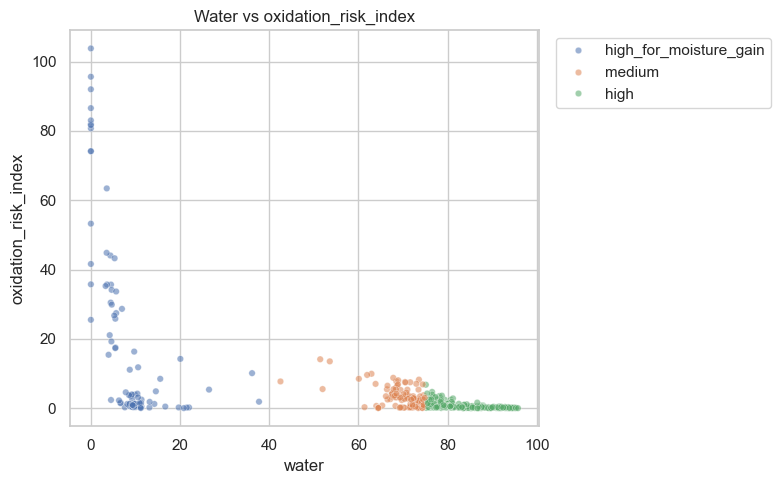

In [6]:
fig, ax = plt.subplots()
sns.histplot(foods["water"].dropna(), bins=40, ax=ax)
for x, lab in [(20, "20"), (50, "50"), (75, "75")]:
    ax.axvline(x, color="crimson", ls="--", lw=1)
    ax.text(x, ax.get_ylim()[1] * 0.9, lab, color="crimson")
ax.set_title("Water with moisture_class cuts")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
sns.histplot(foods["oxidation_risk_index"].dropna(), bins=40, ax=ax)
ax.axvline(0, color="crimson", ls="--")
ax.axvline(10, color="crimson", ls="--")
ax.set_title("oxidation_risk_index with oxidation-band cuts")
plt.tight_layout()
plt.show()

display(foods.groupby("moisture_class")["water"].describe())
display(foods.groupby("food_risk_profile")["oxidation_risk_index"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=foods, x="water", y="oxidation_risk_index",
    hue="moisture_barrier_requirement", alpha=0.55, s=22, ax=ax,
)
ax.set_title("Water vs oxidation_risk_index")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Mapping IFCT `grup` → packaging requirement category

,grup,packaging_category,n_foods,mapped
5,Marine Fish,"Fresh meat, MAP",92,True
2,Other Vegetables,"Fruits, Vegetables, Salads",78,True
0,Fruits,"Fruits, Vegetables, Salads",68,True
3,Animal Meat,"Meat, MAP",63,True
1,Green Leafy Vegetables,"Fruits, Vegetables, Salads",34,True
13,Condiments and Spices,Instant coffee,33,True
10,Grain Legumes,Peanuts,25,True
9,Cereals and Millets,Bakery products,24,True
11,Nuts and Oil Seeds,Peanuts,21,True
4,Poultry,"Meat, MAP",19,True


foods dropped as unmapped: 2
joined rows vs food rows: 540 vs 542


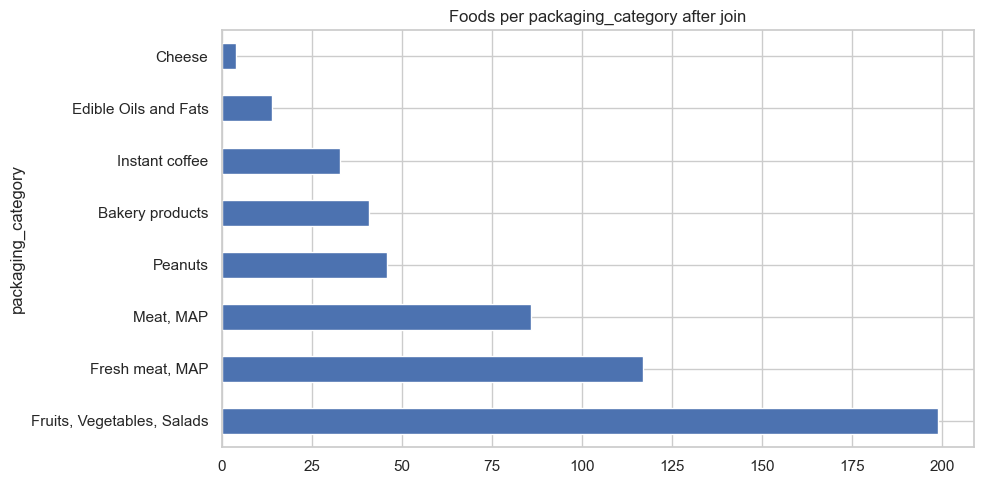

,Min_OTR,Max_OTR,Min_WVTR,Max_WVTR
packaging_category,,,,
Bakery products,30.0,4000.0,600.0,3000.0
Cheese,7.0,10.0,300.0,600.0
Edible Oils and Fats,0.1,2.0,1.0,10.0
"Fresh meat, MAP",20.0,40.0,2.0,4.0
"Fruits, Vegetables, Salads",10000.0,200000.0,10.0,3000.0
Instant coffee,0.2,2.0,0.7,3.0
"Meat, MAP",2.0,20.0,10.0,50.0
Peanuts,0.7,10.0,2.0,8.0


In [7]:
map_df = pd.DataFrame(FOOD_CATEGORY_MAP.items(), columns=["grup", "packaging_category"])
counts = foods["grup"].value_counts().rename("n_foods")
map_df = map_df.merge(counts, left_on="grup", right_index=True, how="left")
map_df["mapped"] = map_df["packaging_category"].notna()
display(map_df.sort_values("n_foods", ascending=False))

print("foods dropped as unmapped:", int(foods["grup"].map(FOOD_CATEGORY_MAP).isna().sum()))
print("joined rows vs food rows:", len(joined), "vs", len(foods))

fig, ax = plt.subplots(figsize=(10, 5))
joined["packaging_category"].value_counts().plot(kind="barh", ax=ax)
ax.set_title("Foods per packaging_category after join")
plt.tight_layout()
plt.show()

display(joined.groupby("packaging_category")[["Min_OTR", "Max_OTR", "Min_WVTR", "Max_WVTR"]].first())


## Food requirement bands (log scale)
These ranges are the target windows materials should fall into. Units are not stored on this table.

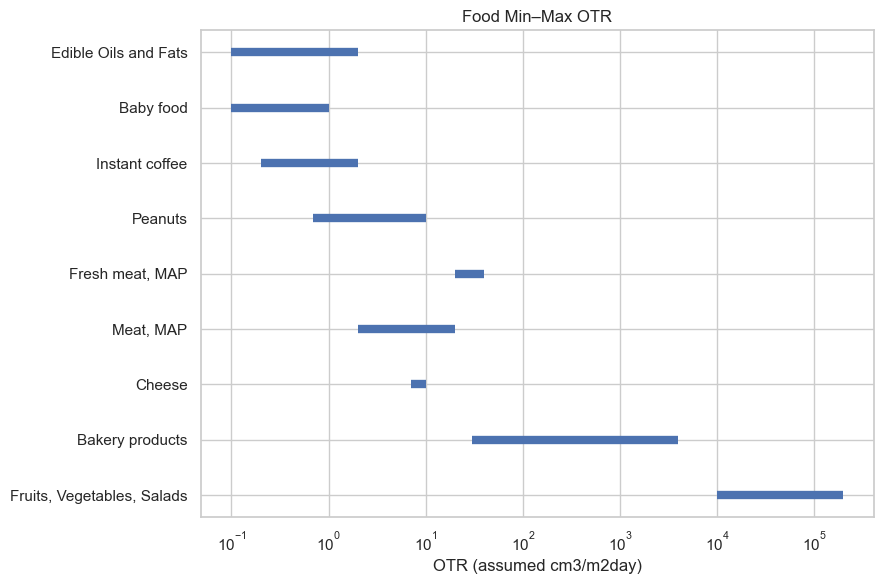

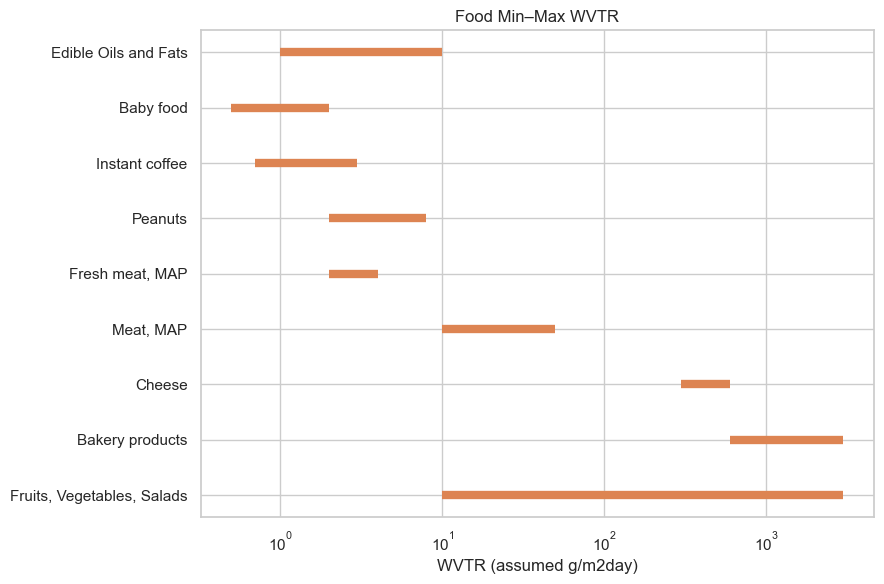

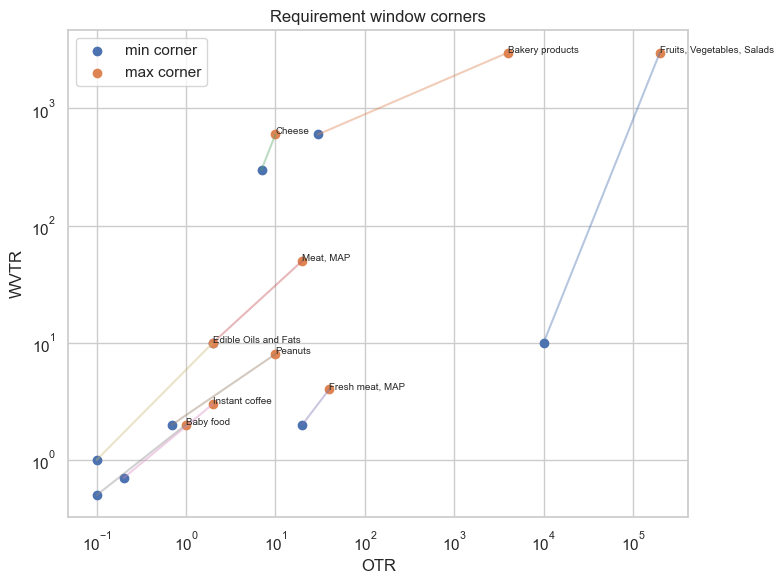

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
ys = np.arange(len(reqs))
ax.hlines(ys, reqs["Min_OTR"], reqs["Max_OTR"], color="C0", lw=6, label="OTR window")
ax.set_yticks(ys)
ax.set_yticklabels(reqs["Food_Category"])
ax.set_xscale("log")
ax.set_xlabel("OTR (assumed cm3/m2day)")
ax.set_title("Food Min–Max OTR")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax.hlines(ys, reqs["Min_WVTR"], reqs["Max_WVTR"], color="C1", lw=6)
ax.set_yticks(ys)
ax.set_yticklabels(reqs["Food_Category"])
ax.set_xscale("log")
ax.set_xlabel("WVTR (assumed g/m2day)")
ax.set_title("Food Min–Max WVTR")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(reqs["Min_OTR"], reqs["Min_WVTR"], label="min corner")
ax.scatter(reqs["Max_OTR"], reqs["Max_WVTR"], label="max corner")
for _, r in reqs.iterrows():
    ax.plot([r["Min_OTR"], r["Max_OTR"]], [r["Min_WVTR"], r["Max_WVTR"]], alpha=0.4)
    ax.text(r["Max_OTR"], r["Max_WVTR"], r["Food_Category"], fontsize=7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("OTR")
ax.set_ylabel("WVTR")
ax.set_title("Requirement window corners")
ax.legend()
plt.tight_layout()
plt.show()


## Do food windows and materials share units?
Materials: mixed (`g/m2day`, `g/m2s`, `cm3/m2day`, `cm3/m2s`, plus permeability units).
Foods: nutrient %/100 g plus unitless requirement numbers.
Alignment is only possible after converting materials onto `g/m2day` and `cm3/m2day`.

,dataset,stated_units,n_values
0,materials WVTR,"g/m2day, g/m2s",141
1,materials OTR,"cm3/m2Pas, cm3/m2day, cm3/m2s, cm3cm/m2Pas, cm...",112
2,food Min/Max_WVTR,not provided (assumed g/m2day),9
3,food Min/Max_OTR,not provided (assumed cm3/m2day),9
4,food composition,IFCT per 100 g food (not barrier units),542


,Food_Category,n_foods,n_materials_WVTR_in_band,n_materials_OTR_in_band,n_materials_both_in_band
0,"Fruits, Vegetables, Salads",199,43,5,0
4,"Fresh meat, MAP",117,0,1,0
3,"Meat, MAP",86,3,28,0
5,Peanuts,46,0,17,0
1,Bakery products,41,18,24,0
6,Instant coffee,33,0,10,0
8,Edible Oils and Fats,14,0,11,0
2,Cheese,4,4,1,0
7,Baby food,0,0,5,0


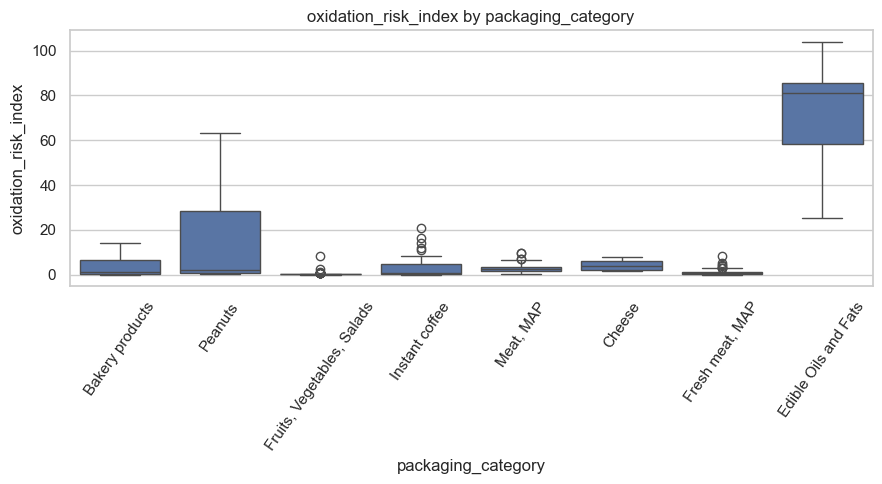

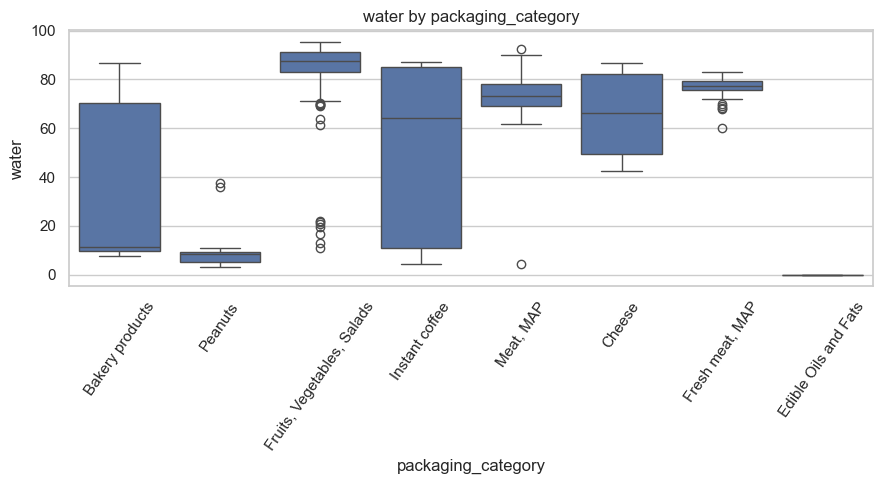

In [12]:
mat["WVTR_g_m2_day"] = [wvtr_to_g_m2_day(v, u) for v, u in zip(mat["WVTR"], mat["WVTR unit"])]
mat["OTR_cm3_m2_day"] = [otr_to_cm3_m2_day(v, u) for v, u in zip(mat["OTR"], mat["OTR unit"])]

unit_table = pd.DataFrame({
    "dataset": ["materials WVTR", "materials OTR", "food Min/Max_WVTR", "food Min/Max_OTR", "food composition"],
    "stated_units": [
        ", ".join(sorted(mat["WVTR unit"].dropna().unique().astype(str))),
        ", ".join(sorted(mat["OTR unit"].dropna().unique().astype(str))),
        "not provided (assumed g/m2day)",
        "not provided (assumed cm3/m2day)",
        "IFCT per 100 g food (not barrier units)",
    ],
    "n_values": [
        int(mat["WVTR"].notna().sum()),
        int(mat["OTR"].notna().sum()),
        len(reqs),
        len(reqs),
        len(foods),
    ],
})
display(unit_table)

cover = []
wv = mat["WVTR_g_m2_day"]
ot = mat["OTR_cm3_m2_day"]
for _, r in reqs.iterrows():
    n_foods = int((joined["packaging_category"] == r["Food_Category"]).sum())
    cover.append({
        "Food_Category": r["Food_Category"],
        "n_foods": n_foods,
        "n_materials_WVTR_in_band": int(wv.between(r["Min_WVTR"], r["Max_WVTR"]).sum()),
        "n_materials_OTR_in_band": int(ot.between(r["Min_OTR"], r["Max_OTR"]).sum()),
        "n_materials_both_in_band": int(
            (wv.between(r["Min_WVTR"], r["Max_WVTR"]) & ot.between(r["Min_OTR"], r["Max_OTR"])).sum()
        ),
    })
display(pd.DataFrame(cover).sort_values("n_foods", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=joined, x="packaging_category", y="oxidation_risk_index", ax=ax)
ax.tick_params(axis="x", rotation=55)
ax.set_title("oxidation_risk_index by packaging_category")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=joined, x="packaging_category", y="water", ax=ax)
ax.tick_params(axis="x", rotation=55)
ax.set_title("water by packaging_category")
plt.tight_layout()
plt.show()


## Findings
- Food composition and material permeability are different quantities; only OTR/WVTR **requirement bands** can be compared to materials.
- Those bands have no unit field; treat them as `cm3/m2day` and `g/m2day` until documented otherwise.
- Most foods sit in `very_high` moisture / `high__medium_oxidation`.
- `Miscellaneous Foods` (2 rows) never join a packaging category.